# Iteration v2 — Feature Engineering + Tree Models

**Objetivo:** Mejorar sobre el baseline de Logistic Regression (ROC AUC: 0.567) en dos frentes:

1. **Nuevas features** — recencia, frecuencia, engagement financiero
2. **Modelos no lineales** — Decision Tree y Random Forest

**Punto de partida:** `data/processed/df_model_baseline_v1.csv`  
**Cutoff temporal:** `2017-02-28` (ya aplicado en el dataset)

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

CUTOFF = pd.Timestamp('2017-02-28')
RANDOM_STATE = 42

## 1. Carga del dataset

In [2]:
df = pd.read_csv('../data/processed/df_model_baseline_v1.csv')

# Convertir fechas
df['txn_last_date'] = pd.to_datetime(df['txn_last_date'])
df['txn_first_date'] = pd.to_datetime(df['txn_first_date'])

print(f"Shape: {df.shape}")
print(f"Churn rate: {df['is_churn'].mean():.2%}")
df.head(3)

Shape: (970960, 21)
Churn rate: 8.99%


,msno,is_churn,city,bd,gender,registered_via,registration_init_time,txn_count,txn_last_date,txn_first_date,...,has_cancelled,auto_renew_last,payment_plan_days_last,plan_list_price_last,actual_amount_paid_last,payment_plan_days_median,actual_amount_paid_median,days_between_first_last_txn,has_txn_history,days_since_registration
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1,5.0,28.0,male,3.0,2013-12-23,0.0,NaT,NaT,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1163.0
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1,13.0,20.0,male,3.0,2013-12-23,0.0,NaT,NaT,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1163.0
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1,13.0,18.0,male,3.0,2013-12-27,0.0,NaT,NaT,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,1159.0


## 2. Feature Engineering v2

Partimos de las features del baseline y agregamos:

| Feature nueva | Concepto | Por qué importa |
|---|---|---|
| `days_since_last_txn` | Recencia | Usuarios que no renuevan hace tiempo → alto riesgo |
| `has_recent_txn` | Flag recencia | Binario: activo en los últimos 30 días |
| `txn_per_day` | Frecuencia | Qué tan seguido renueva |
| `avg_payment` | Engagement financiero | Cuánto paga en promedio |
| `price_discount` | Descuento percibido | Si pagó menos que el precio de lista |
| `plan_consistency` | Estabilidad de plan | Si siempre eligió el mismo plan |

In [3]:
# --- Recencia ---
df['days_since_last_txn'] = (CUTOFF - df['txn_last_date']).dt.days
# Usuarios sin historial → les asignamos un valor alto (nunca tuvieron transacción)
df['days_since_last_txn'] = df['days_since_last_txn'].fillna(df['days_since_last_txn'].max() + 1)

# Flag: tuvo transacción en los últimos 30 días antes del cutoff
df['has_recent_txn'] = (df['days_since_last_txn'] < 30).astype(int)

# --- Frecuencia ---
# txn_per_day: cuántas transacciones por día activo
df['txn_per_day'] = df['txn_count'] / (df['days_between_first_last_txn'].fillna(0) + 1)

# --- Engagement financiero ---
df['avg_payment'] = df['actual_amount_paid_median'].fillna(0)

# --- Descuento: pagó menos del precio de lista? ---
df['price_discount'] = (
    df['plan_list_price_last'].fillna(0) - df['actual_amount_paid_last'].fillna(0)
).clip(lower=0)

# --- Consistencia de plan: mismo plan toda la historia ---
# Si payment_plan_days_last == payment_plan_days_median → siempre eligió el mismo plan
df['plan_consistency'] = (
    df['payment_plan_days_last'].fillna(-1) == df['payment_plan_days_median'].fillna(-2)
).astype(int)

print("Features nuevas creadas:")
new_features = ['days_since_last_txn', 'has_recent_txn', 'txn_per_day', 'avg_payment', 'price_discount', 'plan_consistency']
df[new_features].describe().round(2)

Features nuevas creadas:


,days_since_last_txn,has_recent_txn,txn_per_day,avg_payment,price_discount,plan_consistency
count,970960.00,970960.00,970960.00,970960.00,970960.00,970960.00
mean,717.12,0.09,0.09,15.72,0.02,0.10
std,224.07,0.28,0.39,65.95,1.89,0.29
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,789.00,0.00,0.00,0.00,0.00,0.00
50%,789.00,0.00,0.00,0.00,0.00,0.00
75%,789.00,0.00,0.00,0.00,0.00,0.00
max,789.00,1.00,131.00,2000.00,1599.00,1.00


### 2.1 Verificación rápida: nueva feature vs churn

In [4]:
check_cols = ['days_since_last_txn', 'has_recent_txn', 'txn_per_day', 'avg_payment']
print(df.groupby('is_churn')[check_cols].mean().round(3))

          days_since_last_txn  has_recent_txn  txn_per_day  avg_payment
is_churn                                                               
0                     723.416           0.081        0.082       12.788
1                     653.467           0.143        0.139       45.419


## 3. Definir features y split

In [5]:
# Features baseline (v1)
FEATURES_BASELINE = [
    'txn_count',
    'has_txn_history',
    'auto_renew_last',
    'payment_plan_days_last',
    'plan_list_price_last',
    'actual_amount_paid_last',
    'cancel_count',
    'has_cancelled',
    'days_since_registration',
]

# Features v2: baseline + nuevas
FEATURES_V2 = FEATURES_BASELINE + [
    'days_since_last_txn',
    'has_recent_txn',
    'txn_per_day',
    'avg_payment',
    'price_discount',
    'plan_consistency',
]

TARGET = 'is_churn'

X = df[FEATURES_V2].fillna(0)
y = df[TARGET]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")
print(f"Churn en val: {y_val.mean():.2%}")

Train: (776768, 15) | Val: (194192, 15)
Churn en val: 8.99%


## 4. Función de evaluación

Centralizamos la evaluación para comparar todos los modelos de forma consistente.

In [6]:
def evaluate_model(name, model, X_val, y_val, threshold=0.5):
    """Evalúa un modelo entrenado e imprime métricas clave."""
    y_proba = model.predict_proba(X_val)[:, 1]
    y_pred  = (y_proba >= threshold).astype(int)

    roc = roc_auc_score(y_val, y_proba)
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, zero_division=0)
    rec  = recall_score(y_val, y_pred, zero_division=0)
    f1   = f1_score(y_val, y_pred, zero_division=0)

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  ROC AUC  : {roc:.4f}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 churn : {f1:.4f}")
    print(classification_report(y_val, y_pred, target_names=['no churn', 'churn']))

    return {
        'model': name,
        'roc_auc': roc,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
    }

## 5. Modelos

### 5.1 Logistic Regression (referencia — features v2)

In [7]:
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
res_lr = evaluate_model('Logistic Regression (features v2)', lr, X_val, y_val)


  Logistic Regression (features v2)
  ROC AUC  : 0.5635
  Accuracy : 0.9147
  Precision: 0.7900
  Recall   : 0.0704
  F1 churn : 0.1293
              precision    recall  f1-score   support

    no churn       0.92      1.00      0.96    176726
       churn       0.79      0.07      0.13     17466

    accuracy                           0.91    194192
   macro avg       0.85      0.53      0.54    194192
weighted avg       0.90      0.91      0.88    194192



c:\Users\simon\anaconda3\envs\ds_full\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### 5.2 Decision Tree

`max_depth=5` limita la profundidad para evitar overfitting. Los árboles capturan interacciones entre features y reglas no lineales que la LR no puede aprender.

In [8]:
dt = DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
res_dt = evaluate_model('Decision Tree (max_depth=5)', dt, X_val, y_val)


  Decision Tree (max_depth=5)
  ROC AUC  : 0.6038
  Accuracy : 0.9200
  Precision: 0.7674
  Recall   : 0.1588
  F1 churn : 0.2632
              precision    recall  f1-score   support

    no churn       0.92      1.00      0.96    176726
       churn       0.77      0.16      0.26     17466

    accuracy                           0.92    194192
   macro avg       0.85      0.58      0.61    194192
weighted avg       0.91      0.92      0.90    194192



### 5.3 Random Forest

Ensemble de 100 árboles. Promedia predicciones para reducir varianza. `class_weight='balanced'` compensa el desbalance de clases (~9% churn).

In [9]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
res_rf = evaluate_model('Random Forest (n=100, depth=10, balanced)', rf, X_val, y_val)


  Random Forest (n=100, depth=10, balanced)
  ROC AUC  : 0.6727
  Accuracy : 0.7256
  Precision: 0.1611
  Recall   : 0.4875
  F1 churn : 0.2421
              precision    recall  f1-score   support

    no churn       0.94      0.75      0.83    176726
       churn       0.16      0.49      0.24     17466

    accuracy                           0.73    194192
   macro avg       0.55      0.62      0.54    194192
weighted avg       0.87      0.73      0.78    194192



## 6. Tabla comparativa

In [10]:
# Incluimos el baseline v1 como referencia fija
BASELINE_V1 = {
    'model': 'Logistic Regression (baseline v1)',
    'roc_auc': 0.5673,
    'accuracy': 0.9143,
    'precision': 0.7808,
    'recall': 0.0649,
    'f1': 0.1198,
}

results = pd.DataFrame([BASELINE_V1, res_lr, res_dt, res_rf])
results = results.set_index('model')
results = results.sort_values('roc_auc', ascending=False)

print(results.round(4).to_string())

                                           roc_auc  accuracy  precision  recall      f1
model                                                                                  
Random Forest (n=100, depth=10, balanced)   0.6727    0.7256     0.1611  0.4875  0.2421
Decision Tree (max_depth=5)                 0.6038    0.9200     0.7674  0.1588  0.2632
Logistic Regression (baseline v1)           0.5673    0.9143     0.7808  0.0649  0.1198
Logistic Regression (features v2)           0.5635    0.9147     0.7900  0.0704  0.1293


## 7. Feature Importance — Random Forest

C:\Users\simon\AppData\Local\Temp\ipykernel_13152\1666487197.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='importance', y='feature', palette='Blues_r', ax=ax)


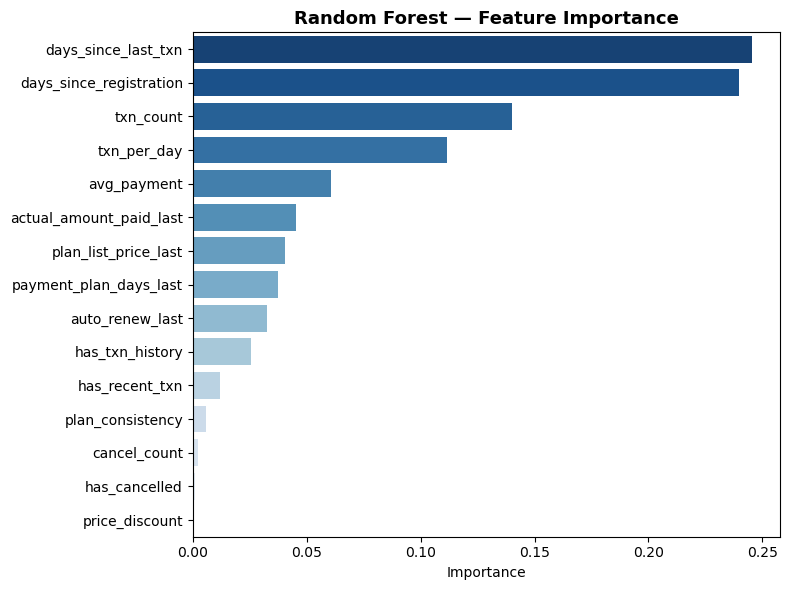

                feature  importance
    days_since_last_txn    0.245453
days_since_registration    0.239806
              txn_count    0.140139
            txn_per_day    0.111642
            avg_payment    0.060738
actual_amount_paid_last    0.045353
   plan_list_price_last    0.040320
 payment_plan_days_last    0.037229
        auto_renew_last    0.032605
        has_txn_history    0.025598
         has_recent_txn    0.011797
       plan_consistency    0.005668
           cancel_count    0.002445
          has_cancelled    0.000828
         price_discount    0.000379


In [11]:
importance = pd.DataFrame({
    'feature': FEATURES_V2,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=importance, x='importance', y='feature', palette='Blues_r', ax=ax)
ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print(importance.to_string(index=False))

## 8. Análisis de threshold — Random Forest

In [12]:
y_proba_rf = rf.predict_proba(X_val)[:, 1]
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]
threshold_rows = []

for t in thresholds:
    y_pred_t = (y_proba_rf >= t).astype(int)
    threshold_rows.append({
        'threshold': t,
        'precision': precision_score(y_val, y_pred_t, zero_division=0),
        'recall': recall_score(y_val, y_pred_t, zero_division=0),
        'f1': f1_score(y_val, y_pred_t, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)
print(threshold_df.round(4).to_string(index=False))

 threshold  precision  recall     f1
       0.5     0.1611  0.4875 0.2421
       0.4     0.1088  0.8435 0.1927
       0.3     0.0949  0.9785 0.1729
       0.2     0.0922  0.9926 0.1688
       0.1     0.0900  1.0000 0.1651


## 9. Conclusiones

Completar después de correr el notebook con los resultados reales.

**Preguntas a responder:**
- ¿Cuánto mejoró el ROC AUC respecto al baseline v1 (0.567)?
- ¿Qué feature nueva aportó más según el Random Forest?
- ¿`days_since_last_txn` resultó ser tan importante como se esperaba?
- ¿Con qué threshold queda un recall aceptable para el negocio?

**Próximos pasos:**
- Probar LightGBM (más rápido y potente que RF)
- Agregar features de user logs (comportamiento de escucha)
- Cross-validation en lugar de un solo split